# CIFAR-100 — Custom ResNet-18

A custom implementation of ResNet-18 adapted for CIFAR-10's 32×32 input.
Uses `BasicBlock` with `_make_layer` to stack 2 blocks per stage (4 stages),
matching the original ResNet-18 architecture but without the 7×7 stem
and initial max-pooling (which would shrink 32×32 images too aggressively).

## Imports

In [1]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim

from utils.dataset import get_cifar100_dataloaders, CIFAR100_CLASSES
from utils.training import fit, test_accuracy
from utils.callbacks import ModelCheckpoint
from utils.plotting import plot_training_curves, show_sample_batch

## Device Setup

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
print(f'Using device: {device}')

Using device: cuda


## Data Pipeline

In [3]:
batch_size = 256

trainloader, valloader, testloader = get_cifar100_dataloaders(
    batch_size=batch_size, num_workers=4, img_size=32,
)

print(f'Train batches: {len(trainloader)} | Val batches: {len(valloader)} | Test batches: {len(testloader)}')

C:\Users\asmit\PycharmProjects\CIFAR_10\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train batches: 157 | Val batches: 40 | Test batches: 40


## Visualize Sample Batch

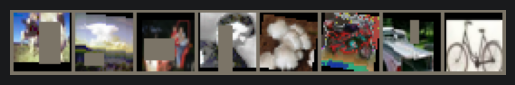

cattle plain tractor woman mushroom motorcycle pickup_truck bicycle


In [4]:
show_sample_batch(trainloader, CIFAR100_CLASSES)

## Model Definition

### BasicBlock
The standard ResNet basic block: two 3×3 convolutions with BatchNorm
and a shortcut connection (identity or 1×1 projection).

### ResNet18
4 stages with 2 `BasicBlock`s each — [2, 2, 2, 2] — totaling ~11M parameters.

In [5]:
class SEBlock(nn.Module):
    def __init__(self, c, r=16):
        super(SEBlock, self).__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(c, c  // r, bias=False),
            nn.ReLU(),
            nn.Linear(c // r, c, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.se(x).view(x.size(0), -1, 1, 1)

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes),
            )

        self.se = SEBlock(planes, r=16)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)
        out += self.shortcut(x)
        out = F.relu(out)
        return out


class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNet18, self).__init__()
        self.in_planes = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        self.layer1 = self._make_layer(64, 2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(BasicBlock(self.in_planes, planes, s))
            self.in_planes = planes
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out

## Initialize Model & Print Summary

In [6]:
model = ResNet18(100).to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
      (se): SEBlock(
        (se): Sequential(
          (0): AdaptiveAvgPool2d(output_size=1)
          (1): Flatten(start_dim=1, end_dim=-1)
          (2): Linear(in_features=64, out_features=4, bias=False)
          (3): ReLU()
          (4): Linear(in_features=4, out_features=64, bias=False)
          (5): Sigmoid()
        )
      )
    )
    (1): BasicBlock

## Training Configuration

In [7]:
criterion = nn.CrossEntropyLoss()
epochs = 120
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

# scheduler = optim.lr_scheduler.OneCycleLR(
#     optimizer,
#     max_lr=0.1,
#     steps_per_epoch=len(trainloader),
#     epochs=epochs,
#     pct_start=0.3,
#     anneal_strategy='cos',
#     div_factor=25,
#     final_div_factor=1e4,
# )

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

scaler = torch.amp.GradScaler('cuda')
NAME = 'resnet18__se_100'
checkpoint = ModelCheckpoint(
    model=model,
    checkpoint_path=f'../checkpoint/{NAME}_latest.pth',
    best_model_path=f'../checkpoint/{NAME}_best.pth',
    mode='max',
    verbose=True,
)

## Training Loop

In [8]:
train_losses, val_losses, val_accuracies = fit(
    model, trainloader, valloader, criterion,
    optimizer, scheduler, scaler, device, epochs, checkpoint,
    step_scheduler_per_batch=False
)

[ModelCheckpoint] New best (max): 11.0800 — saved to ..\checkpoint\resnet18__se_100_best.pth
Epoch [ 1/120]  Train Loss: 4.2162  Val Loss: 3.7778  Val Acc: 11.08%  LR: 0.009998  Time: 18.83s
[ModelCheckpoint] New best (max): 16.3600 — saved to ..\checkpoint\resnet18__se_100_best.pth
Epoch [ 2/120]  Train Loss: 3.7917  Val Loss: 3.5470  Val Acc: 16.36%  LR: 0.009993  Time: 6.07s
[ModelCheckpoint] New best (max): 20.7100 — saved to ..\checkpoint\resnet18__se_100_best.pth
Epoch [ 3/120]  Train Loss: 3.5301  Val Loss: 3.2496  Val Acc: 20.71%  LR: 0.009985  Time: 6.04s
[ModelCheckpoint] New best (max): 25.5600 — saved to ..\checkpoint\resnet18__se_100_best.pth
Epoch [ 4/120]  Train Loss: 3.2896  Val Loss: 2.9396  Val Acc: 25.56%  LR: 0.009973  Time: 6.37s
[ModelCheckpoint] New best (max): 29.1700 — saved to ..\checkpoint\resnet18__se_100_best.pth
Epoch [ 5/120]  Train Loss: 3.0822  Val Loss: 2.7676  Val Acc: 29.17%  LR: 0.009957  Time: 6.19s
[ModelCheckpoint] New best (max): 30.8200 — saved

## Restore Best Weights & Test Evaluation

In [9]:
checkpoint.restore_best_weights()

overall_acc, per_class = test_accuracy(model, testloader, CIFAR100_CLASSES, device)
print(f'\nOverall Test Accuracy: {overall_acc:.2f}%\n')
for name, acc in per_class.items():
    print(f'  {name:5s}: {acc:.1f}%')

[ModelCheckpoint] Restored best weights from ..\checkpoint\resnet18__se_100_best.pth (score=74.7500)

Overall Test Accuracy: 73.42%

  apple: 88.0%
  aquarium_fish: 83.0%
  baby : 63.0%
  bear : 53.0%
  beaver: 64.0%
  bed  : 73.0%
  bee  : 78.0%
  beetle: 79.0%
  bicycle: 84.0%
  bottle: 84.0%
  bowl : 51.0%
  boy  : 56.0%
  bridge: 82.0%
  bus  : 68.0%
  butterfly: 71.0%
  camel: 77.0%
  can  : 78.0%
  castle: 82.0%
  caterpillar: 65.0%
  cattle: 67.0%
  chair: 89.0%
  chimpanzee: 90.0%
  clock: 71.0%
  cloud: 84.0%
  cockroach: 86.0%
  couch: 60.0%
  crab : 74.0%
  crocodile: 64.0%
  cup  : 81.0%
  dinosaur: 68.0%
  dolphin: 69.0%
  elephant: 73.0%
  flatfish: 72.0%
  forest: 62.0%
  fox  : 76.0%
  girl : 58.0%
  hamster: 79.0%
  house: 76.0%
  kangaroo: 67.0%
  keyboard: 93.0%
  lamp : 72.0%
  lawn_mower: 86.0%
  leopard: 73.0%
  lion : 79.0%
  lizard: 47.0%
  lobster: 63.0%
  man  : 49.0%
  maple_tree: 65.0%
  motorcycle: 94.0%
  mountain: 90.0%
  mouse: 60.0%
  mushroom: 75.0%
  

## Training Curves

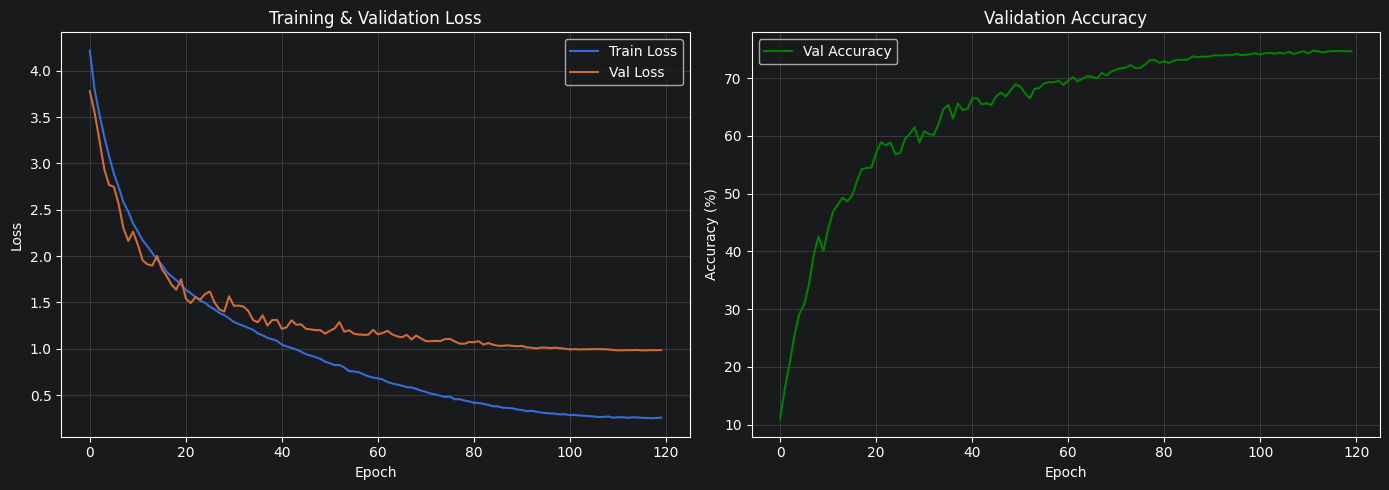

In [10]:
plot_training_curves(train_losses, val_losses, val_accuracies)